# Plot vehicle volume at FR-Capitole
- This script is used to plot vehicle data from UTD19 dataset.

In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import folium
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from staticmap import StaticMap, CircleMarker, Line
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.colors import LinearSegmentedColormap, Normalize
import math
from PIL import Image
import matplotlib.gridspec as gridspec
home_path = '/gws/nopw/j04/duicv/yuansun/'

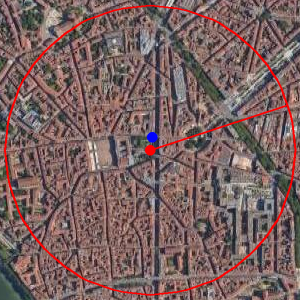

In [2]:
# Define latitude and longitude
lat_flux, lon_flux = 43.6045, 1.4454
lat_detect, lon_detect = 43.6049067, 1.4454988
radius_m = 500  # meters

# Create a static map object
m = StaticMap(300, 300, url_template="https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}",
               tile_size=256)
#m = StaticMap(800, 800, url_template="https://a.tile.openstreetmap.org/{z}/{x}/{y}.png")

# Add markers
m.add_marker(CircleMarker((lon_flux, lat_flux), "red", 10))  # Flux site
m.add_marker(CircleMarker((lon_detect, lat_detect), "blue", 10))  # Detection site
num_points = 100  # More points for a smoother circle
circle_points = []
for i in range(num_points):
    angle = 2 * math.pi * i / num_points  # Divide the circle into equal parts
    dlat = (radius_m / 111320) * math.cos(angle)  # Approximate conversion for latitude
    dlon = (radius_m / (111320 * math.cos(math.radians(lat_flux)))) * math.sin(angle)  # Longitude adjusts for latitude
    circle_points.append((lon_flux + dlon, lat_flux + dlat))
circle_points.append(circle_points[0])    
#m.add_polygon(Polygon(circle_points, fill_color=None, outline_color='red'))
# https://github.com/komoot/staticmap/blob/708b856cca5a15b4874da833487c38bce87fd635/staticmap/staticmap.py#L91
m.add_line(Line(circle_points, "red", 2))
m.add_line(Line([(lon_flux, lat_flux), circle_points[20]], "red", 2))
image = m.render()
image

In [3]:
def meters_per_pixel(lat, zoom):
    return 156543.03392 * math.cos(math.radians(lat)) / (2**zoom)

zoom = 15  # zoom level
width, height = 300, 300  # image size
mpp = meters_per_pixel(lat_flux, zoom)  # meters per pixel at center latitude

half_width_m = (width / 2) * mpp
half_height_m = (height / 2) * mpp

# Convert meters to degrees approximately
lat_extent = half_height_m / 111320
lon_extent = half_width_m / (111320 * math.cos(math.radians(lat_flux)))

lat_min_raw = lat_flux - lat_extent
lat_max_raw = lat_flux + lat_extent
lon_min_raw = lon_flux - lon_extent
lon_max_raw = lon_flux + lon_extent

print("Extent:")
print(f"Latitude: {lat_min_raw} – {lat_max_raw}, delta: {lat_max_raw - lat_min_raw}")
print(f"Longitude: {lon_min_raw} – {lon_max_raw}, delta: {lon_max_raw - lon_min_raw}")

Extent:
Latitude: 43.599838657289666 – 43.60916134271034, delta: 0.009322685420670496
Longitude: 1.4389627278104857 – 1.4518372721895143, delta: 0.012874544379028574


In [4]:
proj = ccrs.PlateCarree()
fontsize = 8
labelsize = 6
labelcolor = '#6b6b6b'
textcolor = '#000000'
radius_m=500
boundarywidth = 0.5
pad=2
xwidth=0.5
length=4
linewidth=0.5
#lon_min = np.round(lon_min_raw,5)
#lon_max = lon_min + 0.01  # Longitude range
#lat_min =  np.round(lat_min_raw,5)
#lat_max = lat_min + 0.01 # Latitude range
title_list = ['(a) Observation sites', '(b) Diurnal traffic profile']
handletextpad = 0.5

In [5]:
df_capitole = pd.read_csv(f'{home_path}0_urban_traffic/validation/capitole/aadt/FR-Capitole.csv')
df_capitole['timestamp'] = pd.to_datetime(df_capitole['day']) + pd.to_timedelta(df_capitole['interval'], unit='s')
df_capitole_clean = df_capitole[['timestamp', 'flow']].sort_values(by='timestamp', ascending=True)
df_capitole_clean = df_capitole_clean.reset_index(drop=True)
df_capitole_clean['vehicles_per_interval'] = df_capitole_clean['flow'] * (3 / 60) # 3 minutes per interval
df_capitole_clean['date'] = df_capitole_clean['timestamp'].dt.date
df_capitole_clean['hour'] = df_capitole_clean['timestamp'].dt.hour
df_capitole_clean['day_of_week'] = df_capitole_clean['timestamp'].dt.day_name() # all Fridays
df_capitole_clean

,timestamp,flow,vehicles_per_interval,date,hour,day_of_week
0,2008-05-16 00:00:00,120.0,6.0,2008-05-16,0,Friday
1,2008-05-16 00:03:00,100.0,5.0,2008-05-16,0,Friday
2,2008-05-16 00:06:00,110.0,5.5,2008-05-16,0,Friday
3,2008-05-16 00:09:00,120.0,6.0,2008-05-16,0,Friday
4,2008-05-16 00:15:00,140.0,7.0,2008-05-16,0,Friday
...,...,...,...,...,...,...
2957,2008-06-27 23:45:00,260.0,13.0,2008-06-27,23,Friday
2958,2008-06-27 23:48:00,220.0,11.0,2008-06-27,23,Friday
2959,2008-06-27 23:51:00,300.0,15.0,2008-06-27,23,Friday
2960,2008-06-27 23:54:00,220.0,11.0,2008-06-27,23,Friday


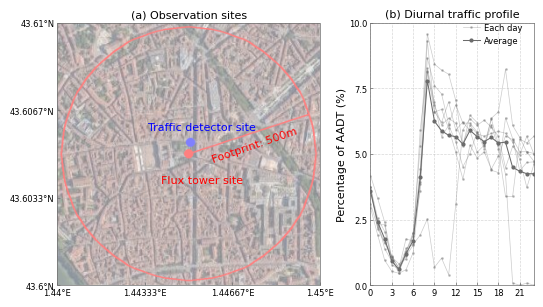

In [8]:
def scale_to(latlon, step=0.01):
    return round(latlon / step) * step

lat_min = scale_to(lat_min_raw)
lat_max = scale_to(lat_max_raw)
lon_min = scale_to(lon_min_raw)
lon_max = scale_to(lon_max_raw)

fig = plt.figure(figsize=(5.5, 3))
# Define gridspec to control subplot sizes
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], figure=fig)  # Adjust width ratio as needed

# Create subplots with custom widths
ax1 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())  # Wider
ax2 = fig.add_subplot(gs[1])
#ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree()) 
#ax2 = fig.add_subplot(1, 2, 2)
ax = [ax1, ax2]
ax1.imshow(image,  extent=[lon_min, lon_max, lat_min, lat_max],
           transform=ccrs.PlateCarree(), alpha=0.5, aspect='equal')  # Set geo-coordinates
#ax1.set_aspect('equal', adjustable='datalim')
ax1.text(lon_detect, lat_detect-0.001, "Flux tower site", fontsize=fontsize, 
         color='red', ha="center", transform=proj)
ax1.text(lon_detect, lat_detect+0.001, "Traffic detector site", fontsize=fontsize, color='blue', ha="center", transform=proj)
ax1.text(lon_detect+0.002, lat_detect-0.0002, f"Footprint: 500m", rotation=19,
        fontsize=fontsize, color='red', ha="center", transform=proj)

# Set labels and ticks
ax1.set_xticks(np.linspace(lon_min, lon_max, 4), crs=proj)
ax1.set_yticks(np.linspace(lat_min, lat_max, 4), crs=proj)
ax1.yaxis.set_major_formatter(LatitudeFormatter())
ax1.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
ax1.tick_params(axis='both', which='both', left = True, right = False, labelleft=True, colors=labelcolor, labelsize=labelsize, labelcolor=textcolor,
               pad=pad, width=xwidth,length=length/2, direction='in')
diurnal_profiles = []
for date in np.unique(df_capitole_clean['date']):
    df_date = df_capitole_clean[df_capitole_clean['date'] == date]
    date_daily_flow = df_capitole_clean.groupby('date')['vehicles_per_interval'].sum()
    date_daily_flow_AADT = date_daily_flow.mean().item()
    date_diurnal = 100 * df_date.groupby('hour')['flow'].mean() / date_daily_flow_AADT
    diurnal_profiles.append(date_diurnal)
    ax2.plot(date_diurnal.index, date_diurnal.values, label='Each day', linewidth=linewidth, color=labelcolor, 
             marker='o', markersize=1, alpha = 0.35)
df_diurnal_all = pd.concat(diurnal_profiles, axis=1).mean(axis=1)
ax2.plot(df_diurnal_all.index, df_diurnal_all.values, label="Average", 
         linewidth=linewidth*1.5, color=labelcolor, marker='o', markersize=2)    
ax2.tick_params(axis='both', which='both', left = True, right = False, labelleft=True, colors=labelcolor, labelsize=labelsize, labelcolor=textcolor,
               pad=pad, width=xwidth,length=length/2, direction='in')
ax2.set_xlim(0, 23)
ax2.set_xticks(np.arange(0, 24, 3))
ax2.set_ylim(0, 10)
ax2.set_yticks(np.linspace(0, 10, 5))
ax2.set_ylabel('Percentage of AADT (%)', fontsize=fontsize, color=textcolor, labelpad=pad)
lines, labels = ax2.get_legend_handles_labels()
lines_sel = [lines[-2:], labels[-2:]]  # Select only the last two entries
legend = fig.legend(lines_sel[0], lines_sel[1], bbox_to_anchor=(0.9, 0.85), 
                    loc='lower center', frameon=False, handletextpad=handletextpad, fontsize=labelsize, ncol=1)
for i in range(2):
    ax[i].set_title(title_list[i], fontsize=fontsize, color=textcolor, pad=pad*2)
    ax[i].grid(True, which='both', axis='both',linestyle='--',linewidth=linewidth, alpha=0.5)
    for spine in ax[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor) 
    ax[i].grid(True, which='both', axis='both',linestyle='--',linewidth=linewidth, alpha=0.5)
plt.subplots_adjust(left=0.05, right=0.975, bottom=0.075, top=0.95, wspace=0.075)   
plt.savefig('site_map_capitole.png', dpi=300)
plt.savefig('site_map_capitole.pdf', dpi=600)

# Description

In [8]:
date_daily_flow

hour
0     3.573022
1     2.416226
2     1.765329
3     0.926045
4     0.602798
5     1.207473
6     1.694950
7     4.140652
8     7.798461
9     6.248910
10    5.884496
11    5.710016
12    5.660919
13    5.371102
14    5.901587
15    5.662216
16    5.468735
17    5.630062
18    5.416837
19    5.451151
20    4.489119
21    4.343687
22    4.247609
23    4.245892
dtype: float64